# Find qgl purest regions

In [ ]:

from matplotlib import pyplot as plt
import matplotlib
import pandas as pd
import uproot
import os
import awkward as ak
import numpy as np

In [4]:
import matplotlib
font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 16}

matplotlib.rc('font', **font)


In [5]:
#input file from latinos
file = 'D:\\Travail\\ZV_analysis\\QGL\\plots_VBS_ZV_20Dec2021_2016_qgl.root'
test=uproot.open(file)['Resolved_DYcr/tree']
jets_df=pd.DataFrame()
for i in test.keys():
    jets_df=jets_df.append(test[i].arrays(library='pd'))


# Bin in jet eta/pt

In [ ]:
eta_cut=2.4
eta_cut_horn=3.5 #for 2017
pt_cut=75
def sort_j0(x):
    if ((x.j0_eta < eta_cut) & (x.j0_pt < pt_cut)): return 'low_eta_low_pt'
    elif((x.j0_eta < eta_cut) & (x.j0_pt >= pt_cut)): return 'low_eta_high_pt'
    elif((x.j0_eta >= eta_cut) & (x.j0_pt < pt_cut)): return 'high_eta_low_pt'
    elif((x.j0_eta >=eta_cut) & (x.j0_pt >= pt_cut)): return 'high_eta_high_pt'
def sort_j1(x):
    if ((x.j1_eta < eta_cut) & (x.j1_pt < pt_cut)): return 'low_eta_low_pt'
    elif((x.j1_eta < eta_cut) & (x.j1_pt >= pt_cut)): return 'low_eta_high_pt'
    elif((x.j1_eta >= eta_cut) & (x.j1_pt < pt_cut)): return 'high_eta_low_pt'
    elif((x.j1_eta >=eta_cut) & (x.j1_pt >= pt_cut)): return 'high_eta_high_pt'
def sort_j2(x):
    if ((x.j2_eta < eta_cut) & (x.j2_pt < pt_cut)): return 'low_eta_low_pt'
    elif((x.j2_eta < eta_cut) & (x.j2_pt >= pt_cut)): return 'low_eta_high_pt'
    elif((x.j2_eta >= eta_cut) & (x.j2_pt < pt_cut)): return 'high_eta_low_pt'
    elif((x.j2_eta >=eta_cut) & (x.j2_pt >= pt_cut)): return 'high_eta_high_pt'
def sort_j3(x):
    if ((x.j3_eta < eta_cut) & (x.j3_pt < pt_cut)): return 'low_eta_low_pt'
    elif((x.j3_eta < eta_cut) & (x.j3_pt >= pt_cut)): return 'low_eta_high_pt'
    elif((x.j3_eta >= eta_cut) & (x.j3_pt < pt_cut)): return 'high_eta_low_pt'
    elif((x.j3_eta >=eta_cut) & (x.j3_pt >= pt_cut)): return 'high_eta_high_pt'
jets_df['j0_region']=jets_df.apply(sort_j0, axis=1)
jets_df['j1_region']=jets_df.apply(sort_j1, axis=1)
jets_df['j2_region']=jets_df.apply(sort_j2, axis=1)
jets_df['j3_region']=jets_df.apply(sort_j3, axis=1)

# Plot quark/gluon population in bisn of jets pt/eta

In [ ]:
from matplotlib.patches import Rectangle
jets= ['j0', 'j1', 'j2', 'j3']
jets_df=jets_df[jets_df['weight']>0]
params = [
        (eta, pt)
        for eta in ['high_eta', 'low_eta']
        for pt in ['_high_pt', '_low_pt']
    ]
regions=[eta + pt for eta,pt in params]
jet_names=['1st jet,', '2nd jet,', '3rd jet,', '4th jet,']
eta_names=[' eta > 2.4 ', ' eta < 2.4 ']
pt_names=['pt > 75 ', 'pt < 75']
p=[(j,eta,pt) for j in jet_names for eta in eta_names for pt in pt_names]
regions_names=[j+ eta + pt for j, eta, pt in p]
fig, ax=plt.subplots(4,4, figsize=(20,20))
for i,jet in enumerate(jets):
    for j,region in enumerate(regions):

        
        print(jet, region)
        ng=jets_df[(jets_df['{}_partfl'.format(jet)]==21) & (jets_df['{}_region'.format(jet)]==region)]['weight'].sum()
        nq=jets_df[(~jets_df['{}_partfl'.format(jet)].isin([0,21])) & (jets_df['{}_region'.format(jet)]==region)]['weight'].sum()
        nothers=jets_df[(jets_df['{}_partfl'.format(jet)]==0) & (jets_df['{}_region'.format(jet)]==region)]['weight'].sum()
        print(ng, nq, nothers)
        x=[int(ng),int( nq), int(nothers)]
        labels='gluons', 'quarks', 'others'
        ax[i,j].pie(x, labels=labels, autopct='%0.1f%%')
        ax[i,j].set_title(regions_names[j+(i*4)])
        
        

autoAxis = ax[0,0]
rec = Rectangle((-1.2,-1.2),2.4,2.4,fill=False,lw=3, edgecolor='orange')
rec = autoAxis.add_patch(rec)
rec.set_clip_on(False)
autoAxis = ax[3,3]
rec = Rectangle((-1.2,-1.2),2.4,2.4,fill=False,lw=3, edgecolor='blue')
rec = autoAxis.add_patch(rec)
rec.set_clip_on(False)
#plt.savefig('D:\\Travail\\ZV_analysis\\QGL\\2018_purity.pdf')



# alternative bar plot representation

0 0
j0 higheta_pt0
0 1
j0 higheta_pt1
0 2
j0 loweta_pt0
0 3
j0 loweta_pt1
1 0
j1 higheta_pt0
1 1
j1 higheta_pt1
1 2
j1 loweta_pt0
1 3
j1 loweta_pt1
2 0
j2 higheta_pt0
2 1
j2 higheta_pt1
2 2
j2 loweta_pt0
2 3
j2 loweta_pt1
3 0
j3 higheta_pt0
3 1
j3 higheta_pt1
3 2
j3 loweta_pt0
3 3
j3 loweta_pt1


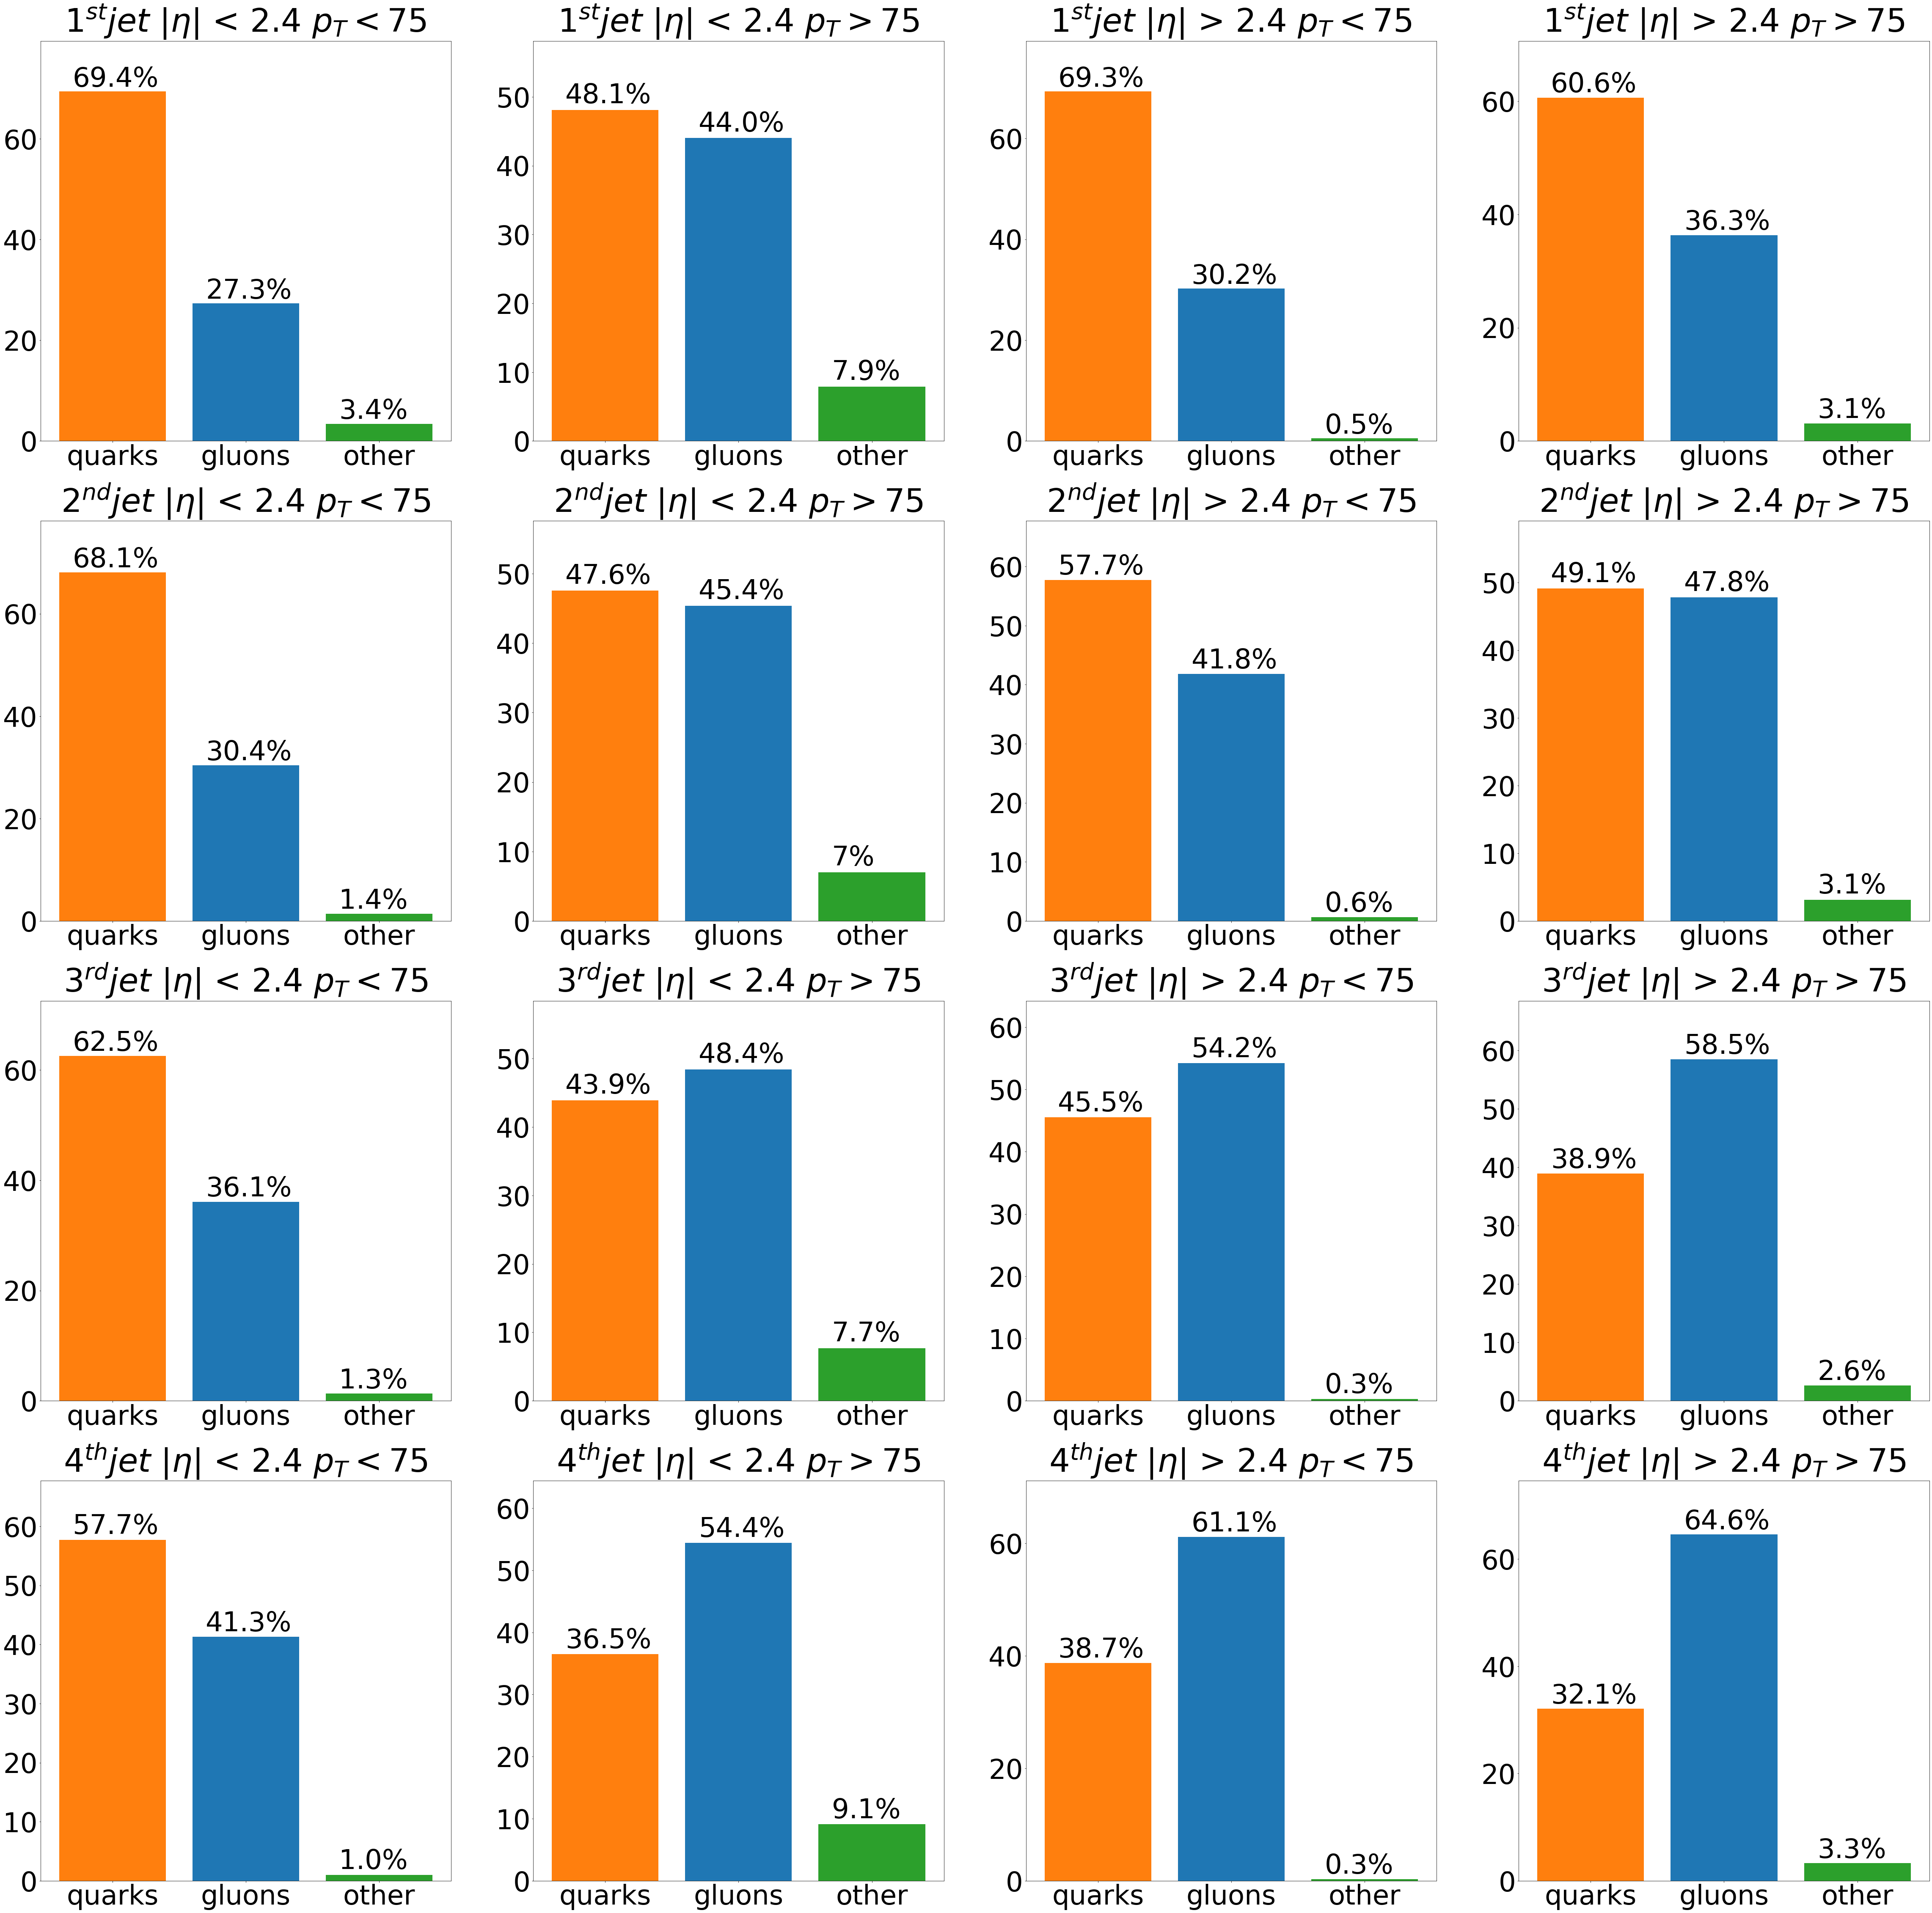

In [21]:
jets= [r'$1^{st} jet$', r'$1^{st} jet$', r'$1^{st} jet$', r'$1^{st} jet$']
font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 64}

matplotlib.rc('font', **font)

params = [
        (eta, pt)
        for eta in ['higheta_', 'loweta_']
        for pt in ['pt0', 'pt1']
    ]
regions=[eta + pt for eta,pt in params]
jet_names=[r'$1^{st} jet$',  r'$2^{nd} jet$',  r'$3^{rd} jet$',  r'$4^{th} jet$']
eta_names=[r' $|\eta|$ < 2.4 ', ' $|\eta|$ > 2.4 ']
pt_names=['$p_{T} < 75$', '$p_{T} > 75$']
p=[(j,eta,pt) for j in jet_names for eta in eta_names for pt in pt_names]
regions_names=[j+ eta + pt for j, eta, pt in p]
values=[[69.4,27.3,3.4], [48.1,44.0,7.9], [69.3,30.2,0.5], [60.6,36.3,3.1],[68.1,30.4,1.4], [47.6,45.4,7], [57.7,41.8,0.6],[49.1,47.8,3.1],
[62.5,36.1,1.3], [43.9,48.4,7.7],[45.5,54.2,0.3], [38.9, 58.5,2.6], [57.7,41.3,1.0], [36.5,54.4,9.1], [38.7,61.1,0.3],[32.1,64.6,3.3]]
fig, ax=plt.subplots(4,4, figsize=(80,80))
for i,jet in enumerate(jets):
    for j,region in enumerate(regions):
        #print(i,j)
        #print(jet, region)
        ax[i,j].bar(x=['quarks', 'gluons', 'other'], height=values[4*i+j], color=[colors[1], colors[0], colors[2]])
        ax[i,j].set_title(regions_names[4*i+j])
        ax[i,j].set_ylim(top = max(values[4*i+j])+10)
        for n, v in enumerate(values[4*i+j]):
            ax[i,j].text(n-0.3,v+1,  str(str(v)+'%'), color='black',)
plt.savefig('purity18.png', bbox_inches='tight')

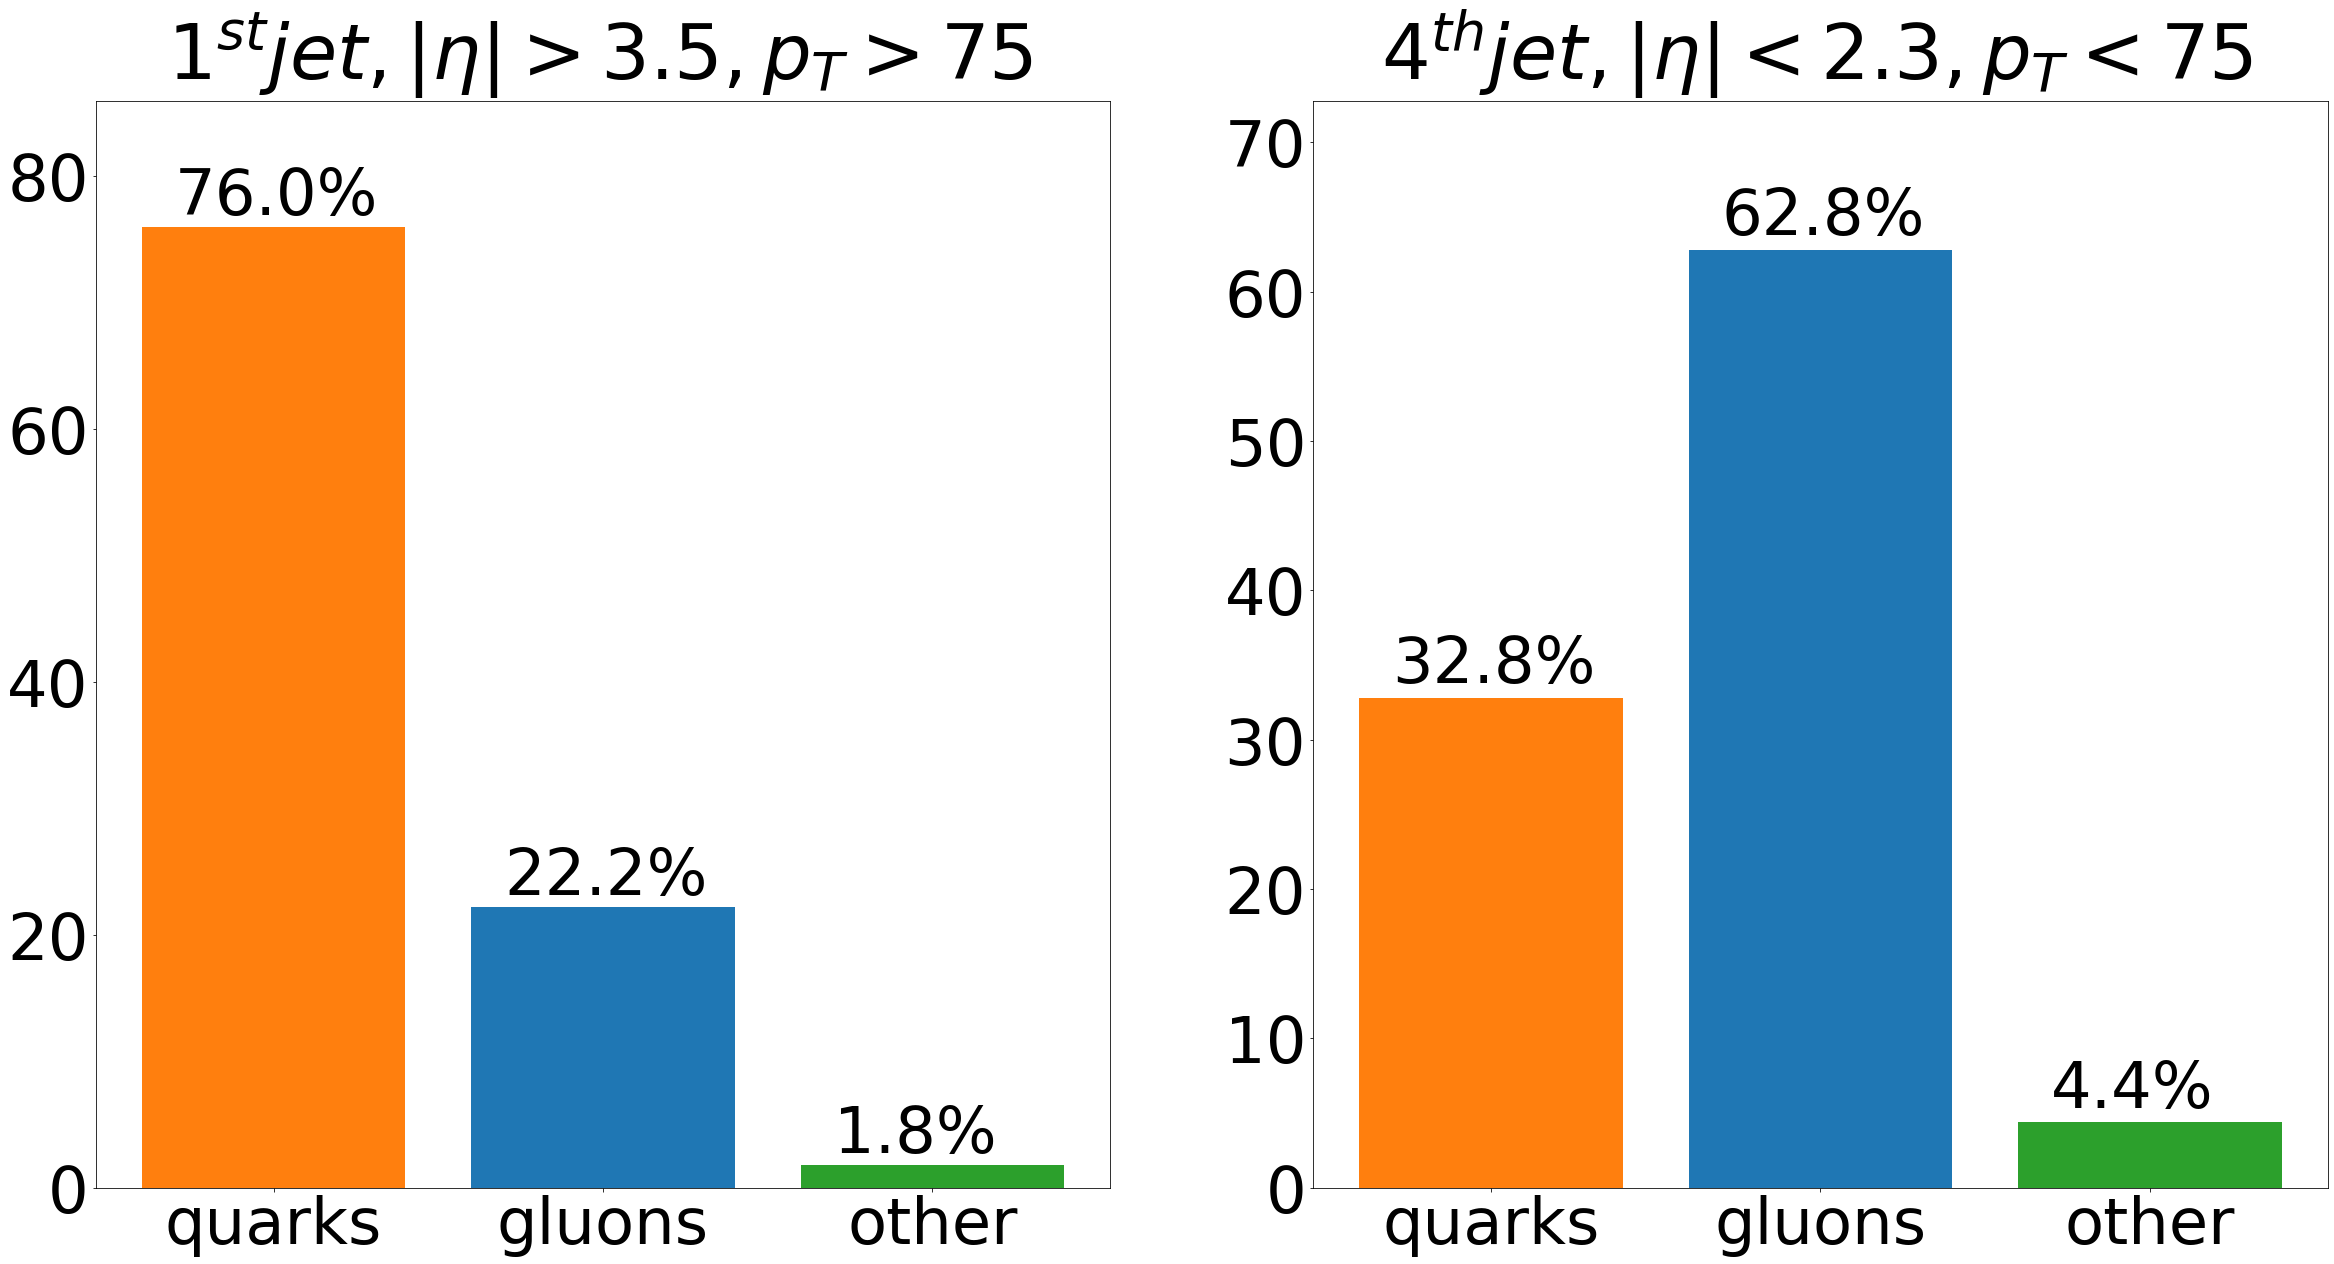

In [22]:
fig, ax=plt.subplots(1,2, figsize=(40,20))
jet_names=[r'$1^{st} jet$',  r'$2^{nd} jet$',  r'$3^{rd} jet$',  r'$4^{th} jet$']
eta_names=[r' $|\eta|$ < 2.4 ', ' $|\eta|$ > 2.4 ']
pt_names=['p_{T} < 75', 'p_{T} > 75']
values=[[76.0,22.2,1.8], [32.8,62.8,4.4]]
regions=[r'$1^{st} jet, |\eta| > 3.5, p_{T} > 75$ ', r'$4^{th} jet, |\eta| < 2.3, p_{T} < 75$ ']
for i, region in enumerate(regions):
    ax[i].bar(x=['quarks', 'gluons', 'other'], height=values[i], color=[colors[1], colors[0], colors[2]])
    ax[i].set_title(regions[i])
    ax[i].set_ylim(top = max(values[i])+10)
    for n, v in enumerate(values[i]):
        ax[i].text(n-0.3,v+1,  str(str(v)+'%'), color='black',)
plt.savefig('purity17.png', bbox_inches='tight')

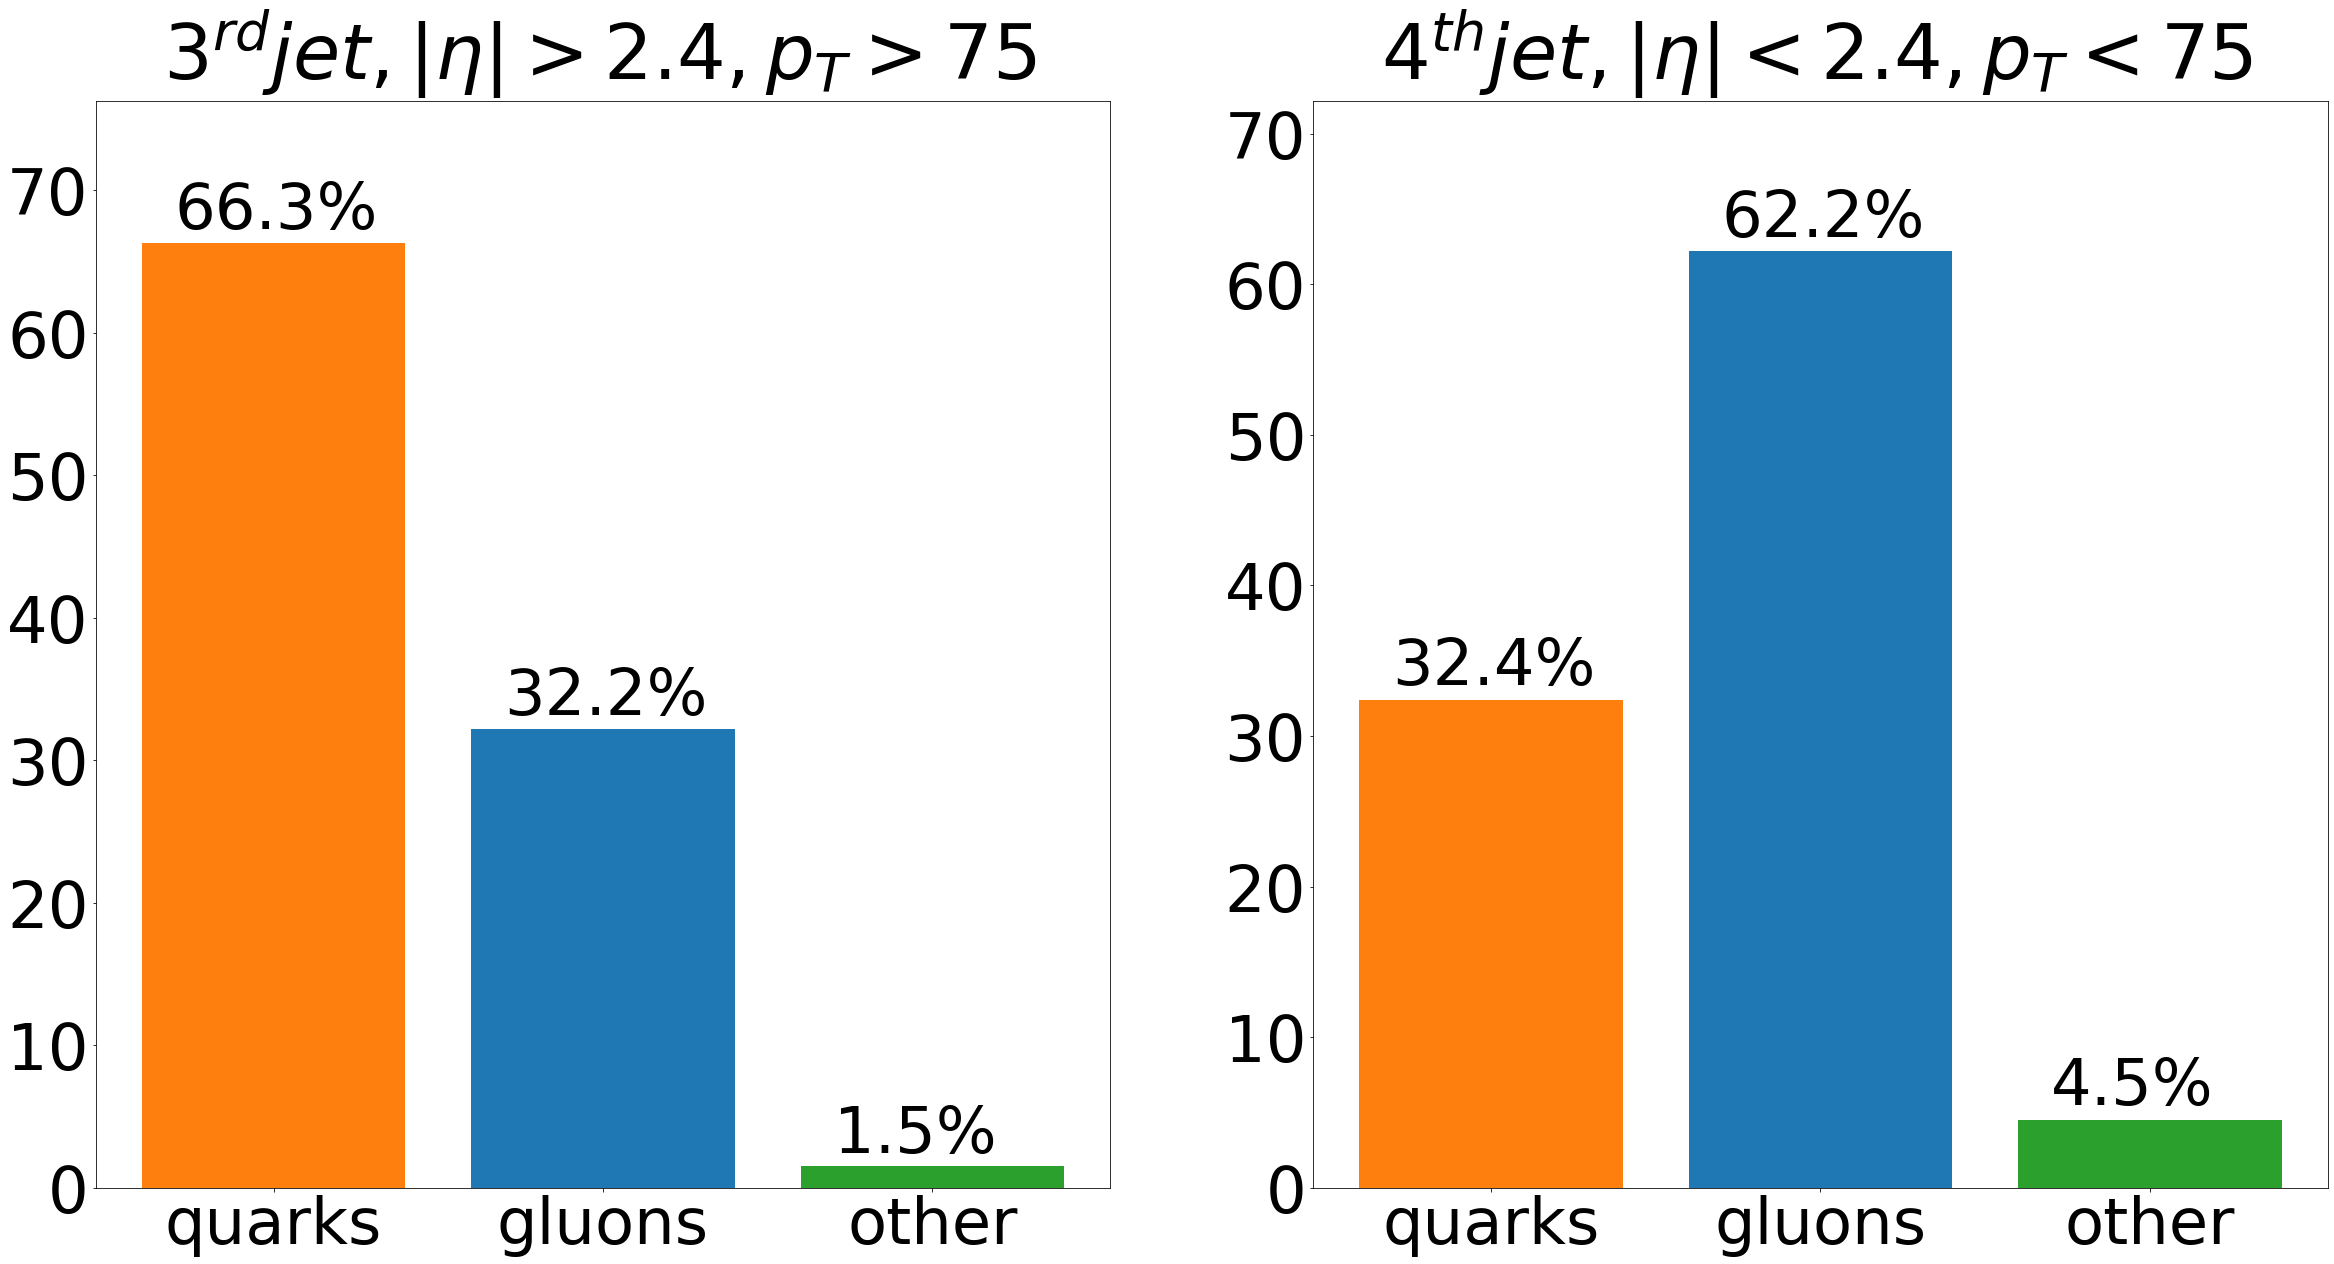

In [23]:
fig, ax=plt.subplots(1,2, figsize=(40,20))
jet_names=[r'$1^{st} jet$',  r'$2^{nd} jet$',  r'$3^{rd} jet$',  r'$4^{th} jet$']
eta_names=[r' $|\eta|$ < 2.4 ', ' $|\eta|$ > 2.4 ']
pt_names=['p_{T} < 75', 'p_{T} > 75']
values=[[66.3,32.2,1.5], [32.4,62.2,4.5]]
regions=[r'$3^{rd} jet, |\eta| > 2.4, p_{T} > 75$ ', r'$4^{th} jet, |\eta| < 2.4, p_{T} < 75$ ']
for i, region in enumerate(regions):
    ax[i].bar(x=['quarks', 'gluons', 'other'], height=values[i], color=[colors[1], colors[0], colors[2]])
    ax[i].set_title(regions[i])
    ax[i].set_ylim(top = max(values[i])+10)
    for n, v in enumerate(values[i]):
        ax[i].text(n-0.3,v+1,  str(str(v)+'%'), color='black',)


plt.savefig('purity16.png', bbox_inches='tight')

# Plot morphing curves from morphing functions ouptut

In [ ]:
# output from morphing
file='D:\\Travail\\ZV_analysis\\QGL\\output_histos_Resolved_DYcr_iter0.root'
qgl_df=uproot.open(file)
qgl_df.keys()
#MC qgl distribs
gluons=qgl_df['j3_gluon_qgl_loweta_pt0;1']
quarks= qgl_df['j0_quark_qgl_higheta_pt1;1']
#data qgl distribs
targetg = qgl_df['DATA_j3_nogen_qgl_loweta_pt0;1']
targetq= qgl_df['DATA_j0_nogen_qgl_higheta_pt1;1']


def get_morphing(qgl, target):
    tx=[]
    ty=[]
    for i,x in enumerate(np.linspace(0.,1.,200)):
        #calculate cdf bin x
        y1 = np.interp(x, bins_count[1:], qgl)
        if y1>1: y1 = 1 
        # calculate moprh with inv target CDF
        y = np.interp(y1, target, bins_count[1:])
        if y>1: y=1
        tx.append(x)
        ty.append(y)
    return tx, ty

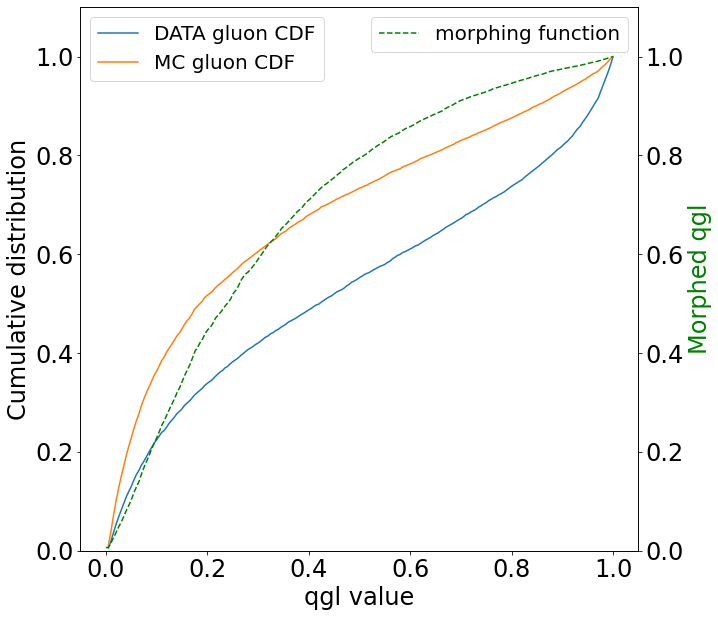

In [26]:
# plots CDFs
import matplotlib
font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 24}



matplotlib.rc('font', **font)

# gluons
fig, ax1=plt.subplots(figsize=(10,10))
#count, bins_count = np.histogram(targetg.values(), bins=np.linspace(0,1,100))

ax2 = ax1.twinx()
count, bins_count= targetg.to_numpy()
pdf = count / sum(count)
targetg_cdf = np.cumsum(pdf)
ax1.plot(bins_count[1:], targetg_cdf, label="DATA gluon CDF")

count, bins_count= gluons.to_numpy()
pdf = count / sum(count)
gluon_cdf = np.cumsum(pdf)
ax1.plot(bins_count[1:], gluon_cdf, label="MC gluon CDF")

#try to calculate morphing: target CDF-1(gluon CDF)
a,b=get_morphing(gluon_cdf, targetg_cdf)
ax2.plot(a,b, label="morphing function", linestyle ='--', c='green')
ax1.set_xlabel('qgl value')
ax1.set_ylabel('Cumulative distribution')
ax2.set_ylabel('Morphed qgl', color='green')
ax1.legend(loc='upper left', fontsize=20)
ax2.legend(loc='upper right', fontsize=20)
#plt.title("j3 et low pt")

ax1.set_ylim(0,1.1)
ax2.set_ylim(0,1.1)
plt.savefig('D:\\Travail\\ZV_analysis\\QGL\\morphing.pdf')